# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

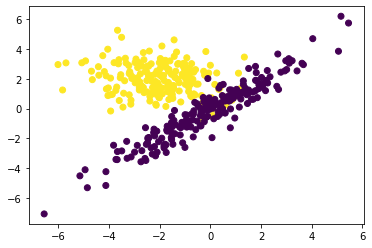

In [3]:
synth= syn.synthetic_data_generator(n=200,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [4]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [5]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.060582,0.626917,0.769333,0.514134
1,0.370277,0.722770,0.444380,0.117667
2,0.388114,0.607190,0.017492,0.779913
3,0.478175,0.664165,0.063602,0.437668
4,0.413239,0.632934,0.074222,0.682049


# ML model setup

In [6]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [7]:
# ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


0.925

In [8]:
# ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)
rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.9125

# Shap test

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


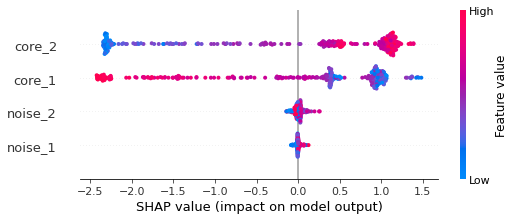

In [9]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [10]:
shap_values[1]

.values =
array([-1.3932582 , -0.39312142, -0.02823696, -0.02910464], dtype=float32)

.base_values =
-0.06290116

.data =
array([0.64615257, 0.58121899, 0.03599428, 0.05011951])

# FAR test - Global version

In [11]:
repeat_train= 5
num_fts= len(train.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train.values.ravel(), 
                                          labels_test.values.ravel(), repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train, test, labels_train,labels_test, 
                                               repeat_train)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


In [12]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [13]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     4.881558e-01
core_1     4.731000e-01
noise_1    3.874415e-02
noise_2    7.806256e-18
dtype: float64

In [14]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.319378
core_1     0.292775
noise_1    0.212433
noise_2    0.166864
dtype: float64

In [15]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.299176
core_1     0.282889
noise_1    0.229271
noise_2    0.178878
dtype: float64

In [16]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     4.921172e-01
core_1     4.813925e-01
noise_1    2.649029e-02
noise_2   -5.594483e-17
dtype: float64

# FAR test - Knn-only local version

In [17]:
X_to_split= x_syn.copy()
Y_to_split= y_syn.copy()

target_index= 1

target_instance= X_to_split.loc[X_to_split.index== target_index]
target_label= Y_to_split.loc[Y_to_split.index== target_index]

X_no_targt= X_to_split.drop(target_instance.index)
Y_no_targt= Y_to_split.drop(index= target_index)

In [18]:
train_1, test_1, labels_train_1, labels_test_1= far.knn_train_test_split(X_no_targt,Y_no_targt,target_instance,
                                                                         target_label,test_size=0.2)

repeat_train= 5
num_fts= len(train_1.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train_1, test_1, labels_train_1.values.ravel(), 
                                          labels_test_1.values.ravel(), repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train_1, test_1, 
                                               labels_train_1.values.ravel(),
                                               labels_test_1.values.ravel(), repeat_train)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


In [20]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# now convert to right stochastic matrix
st_matrix1= far.p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.p_matrix_to_row_stochastic_matrix(p_matrix4)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [21]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.357471
noise_2    0.329647
noise_1    0.162836
core_1     0.150046
dtype: float64

In [22]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.354899
core_1     0.320544
core_2     0.188736
noise_2    0.135821
dtype: float64

In [23]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.327575
core_2     0.248890
noise_1    0.236749
noise_2    0.186787
dtype: float64

In [24]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.335922
core_1     0.330792
noise_2    0.219138
noise_1    0.114147
dtype: float64

# FAR test - Local version PageRank

In [25]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_2     0.340392
noise_2    0.316618
noise_1    0.176329
core_1     0.166661
dtype: float64

In [26]:
far.run_lib_pr(st_matrix2, x_syn.columns)

noise_1    0.337346
core_1     0.309981
core_2     0.198613
noise_2    0.154060
dtype: float64

In [27]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_1     0.319706
core_2     0.249639
noise_1    0.236249
noise_2    0.194406
dtype: float64

In [28]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_2     0.327630
core_1     0.321566
noise_2    0.218854
noise_1    0.131950
dtype: float64

In [29]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_2     0.431868
core_1     0.248013
noise_2    0.186058
noise_1    0.134061
dtype: float64

In [30]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.412854
core_2     0.268056
noise_1    0.193747
noise_2    0.125343
dtype: float64

In [31]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.447635
core_2     0.268899
noise_1    0.149256
noise_2    0.134210
dtype: float64

In [32]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.454222
core_2     0.307195
noise_2    0.133396
noise_1    0.105188
dtype: float64